In [3]:
print("Loading packages")
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import tifffile as tiff

from pyvis.network import Network

from skimage.morphology import skeletonize
from skimage.util import invert
from skimage import io

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle

from skeleton_model import form_networks_all


Loading packages


In [6]:
stages = [3,4]
#run 1-11 separately to split the time up because 12,13 take a long time

#stages = [12]
#stages = [13]

#spatial resolution: number of pixels per micron
#MAKE SURE this matches the ratio used in the skeleton.ijm macro!
pix_micron_ratio = 0.25

microns_per_pixel = 1/pix_micron_ratio

base=2 #intercept term
dist_propn_given=0.08 #multiplier term

path = f"data/skeleton/all/"  

nodes_all_stages, adj_all_stages = form_networks_all(stages,path,microns_per_pixel,base=base,dist_propn=dist_propn_given)


Stage is 3
Image HH3, n=1
Dimensions in pixels 1729x1438
Dimensions in microns 6916.0x5752.0
Unmerged length:63
Merged length:45


Image HH3, n=2
Dimensions in pixels 1814x1569
Dimensions in microns 7256.0x6276.0
Unmerged length:3
Merged length:3


Stage is 4
Image HH4, n=1
Dimensions in pixels 1222x1516
Dimensions in microns 4888.0x6064.0
Unmerged length:348
Merged length:291


Image HH4, n=2
Dimensions in pixels 1863x1498
Dimensions in microns 7452.0x5992.0
Unmerged length:160
Merged length:117


Image HH4, n=3
Dimensions in pixels 1711x2516
Dimensions in microns 6844.0x10064.0
Unmerged length:394
Merged length:307


Image HH4, n=4
Dimensions in pixels 1364x2118
Dimensions in microns 5456.0x8472.0
Unmerged length:380
Merged length:306




In [ ]:
#rewrite this to dump each HH stage individually?
if stages == [12]:
    pickle.dump(nodes_all_stages,open(f"results/skeleton/nodes_list_all_hh12.txt","wb"))
    pickle.dump(adj_all_stages,open(f"results/skeleton/adj_list_all_hh12.txt","wb"))
elif stages == [13]:
    pickle.dump(nodes_all_stages,open(f"results/skeleton/nodes_list_all_hh13.txt","wb"))
    pickle.dump(adj_all_stages,open(f"results/skeleton/adj_list_all_hh13.txt","wb"))
else:
    pickle.dump(nodes_all_stages,open(f"results/skeleton/nodes_list_all_3_to_11.txt","wb"))
    pickle.dump(adj_all_stages,open(f"results/skeleton/adj_list_all_3_to_11.txt","wb"))

In [8]:
def nodes_plot(image,nodes,adj,node_alpha=0.4,edge_alpha=1,im_alpha=1,edge_weights=False,node_weights=False):
    #show skeleton
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(image,cmap=plt.cm.gray,alpha=im_alpha)
    ax.axis('off') 

    size = 1000
    x_min = 100
    y_min = 100
    x_max,y_max = x_min+size,y_min+size



    #calculate nodes and edges
    patches = []
    for i in nodes.index:
        x,y,weight,type = nodes[["x","y","weight","type"]].loc[i]
        if x_min<=x<=x_max and y_min<=y<=y_max: #only plot the valid region
            if type == "junction": #colourings
                circle = Circle((x, y), 1+weight,color="#e2342c")
            else: 
                circle = Circle((x, y), 1+weight,color="#f2ad00")
            patches.append(circle)

            #text labelling
            if node_weights and int(weight)!=76 and int(weight)!=70 and int(weight)!=12: #hacky line to remove overlapping numbers
                ax.text(x, y, str(int(weight)), ha='center', va='center', fontsize=20, color='white',font="arial",weight="bold")
            
            
    p = PatchCollection(patches, alpha=node_alpha,match_original=True)
    ax.add_collection(p)


    #code for edges
    for i in adj:
        for j in adj:
            dist = adj.loc[i,j]
            if dist>0:
                x1,y1=nodes[["x","y"]].loc[i]
                x2,y2=nodes[["x","y"]].loc[j]
                if x_min<=x1<=x_max and y_min<=y1<=y_max:
                    ax.plot([x1,x2],[y1,y2],alpha=edge_alpha,linewidth=5)

                    #text labelling
                    av_x,av_y = (x1+x2)/2, (y1+y2)/2
                    if edge_weights and int(dist)!=4 and int(dist)!=244:
                        ax.text(av_x, av_y, str(int(dist)), ha='left', va='bottom', fontsize=20, color='white' ,font="arial",weight="bold")


    

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)

    plt.show()

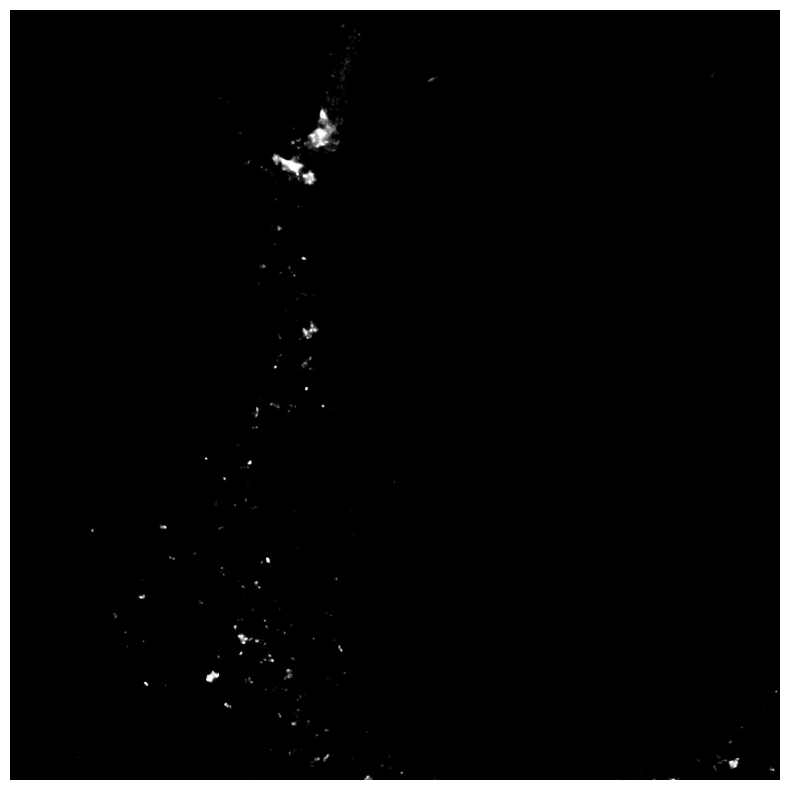

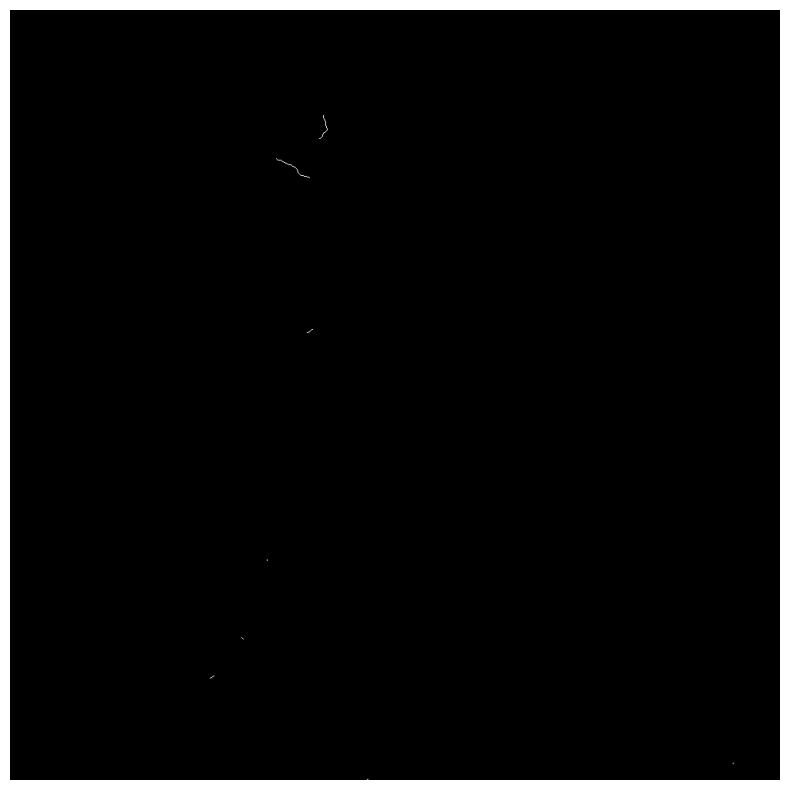

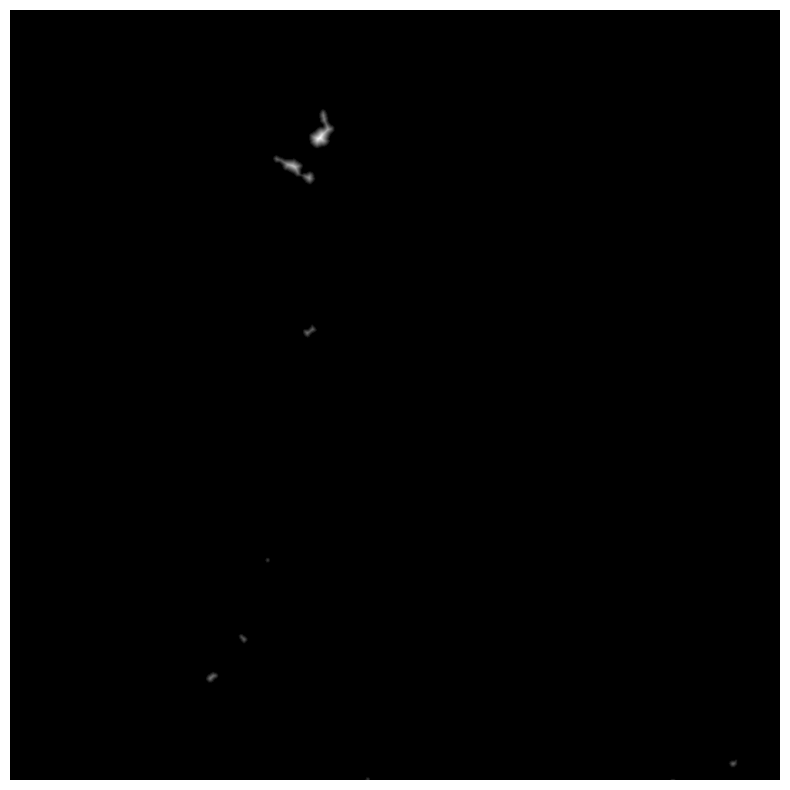

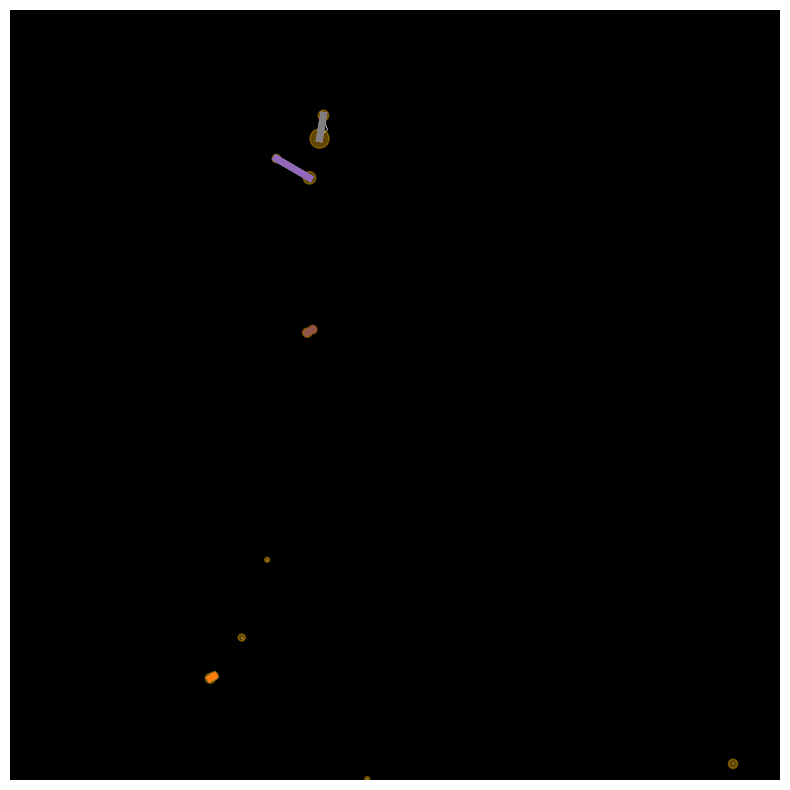

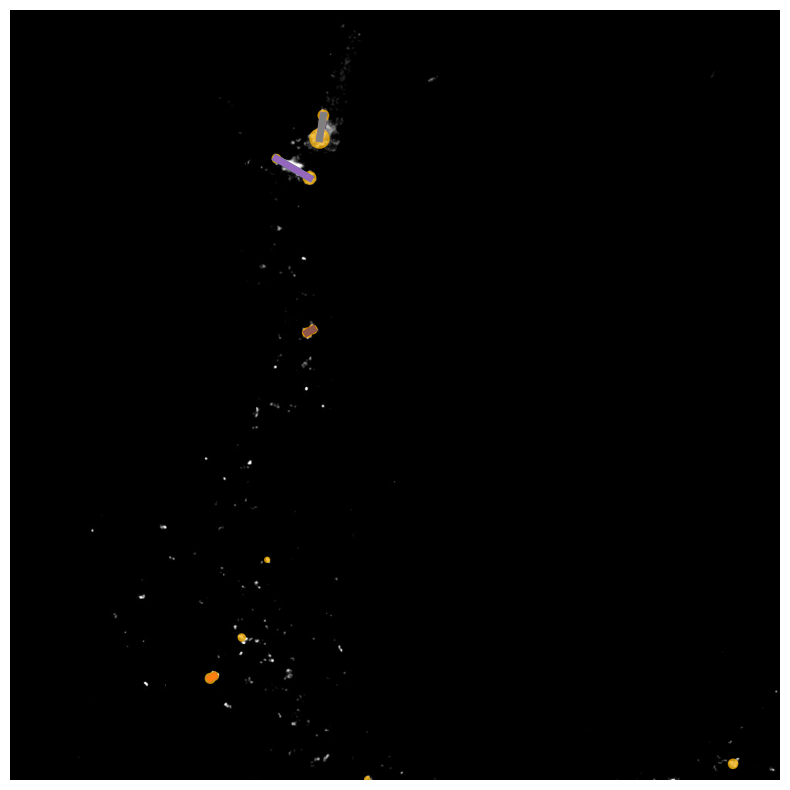

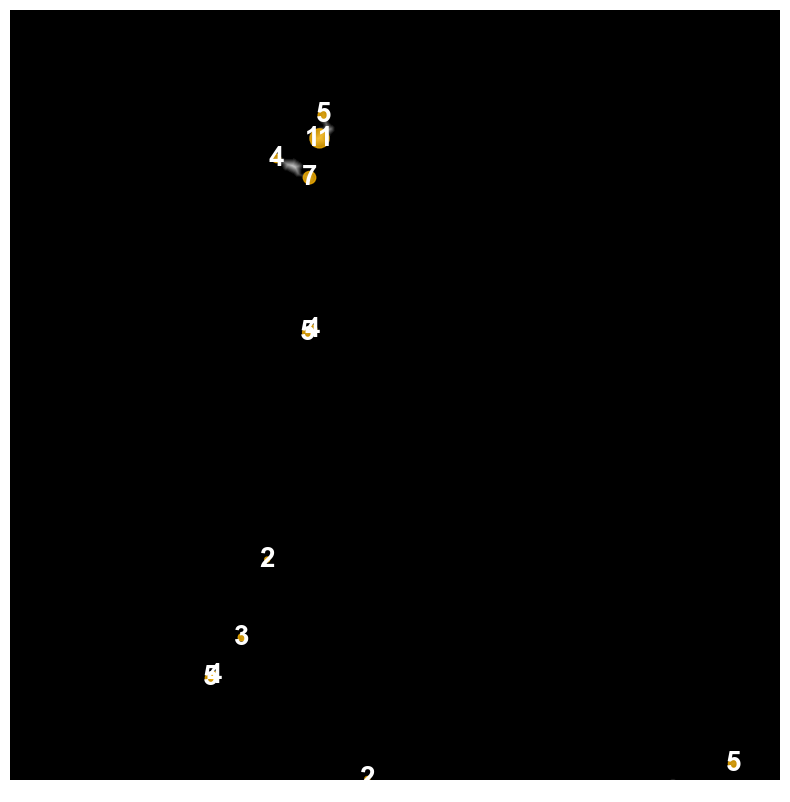

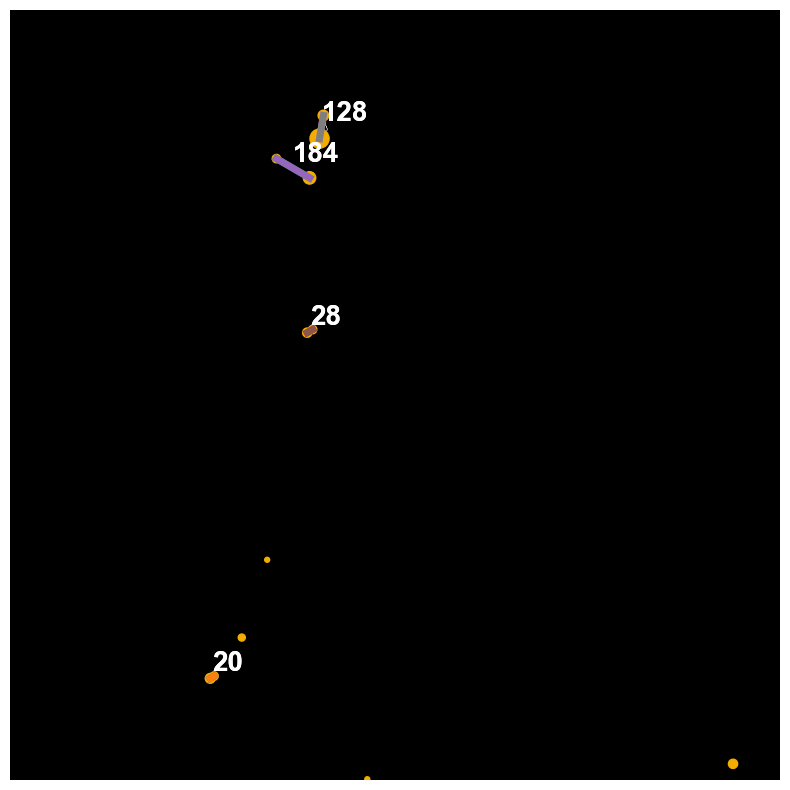

In [15]:
n=1
stage=3
nodes = nodes_all_stages[0][n-1]
adj = adj_all_stages[0][n-1]

original = cv2.imread(f'{path}n{n}_hh{stage}_plain_scaled.jpg')
skele = tiff.imread(f'{path}n{n}_hh{stage}_skeleton.tif')
dists = tiff.imread(f"{path}n{n}_hh{stage}_distmap.tif") 
black = cv2.imread(f"{path}black.jpg") 

image_plot(original)
image_plot(skele)
image_plot(dists)


nodes_plot(skele,nodes,adj)
nodes_plot(original,nodes,adj,node_alpha=0.7)

nodes_plot(dists,nodes,adj,edge_alpha=0,node_alpha=0.8,node_weights=True)
nodes_plot(skele,nodes,adj,node_alpha=1,edge_weights=True)


